<a href="https://colab.research.google.com/github/fknbtrd/netology_homework/blob/main/%D0%9F%D1%80%D0%BE%D0%B1%D0%BB%D0%B5%D0%BC%D0%B0%20%D0%BA%D0%B0%D1%87%D0%B5%D1%81%D1%82%D0%B2%D0%B0%20%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Загрузка данных

In [ ]:
df = pd.read_csv('train.csv')
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Модель на условно необработанном датасете

In [ ]:
# оставляем только числовые признаки
df_simple = df.select_dtypes(include=['int64','float64'])

# удаляем строки с пропусками
df_simple = df_simple.dropna()

df_simple.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


Обучение первой модели

In [ ]:
X = df_simple.drop('Survived', axis=1)
y = df_simple['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict(X_test)

acc_simple = accuracy_score(y_test, pred)

print("Accuracy на необработанных данных:", acc_simple)

Accuracy на необработанных данных: 0.6993006993006993


Снова загружаем данные, проверяем пропуски, смотрим потерю данных и заполняем пропуски

In [ ]:
df = pd.read_csv('train.csv')
df = df.drop(['PassengerId','Name','Ticket','Cabin'], axis=1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
df.isnull().sum()
lost_percent = df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100

print("Процент пропущенных значений:", round(lost_percent,2), "%")

Процент пропущенных значений: 2.51 %


In [ ]:
# Берем средние значения возраста
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Берем частые значения посадок
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

Кодирование категориальных признаков

In [ ]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


Проверка выбросов

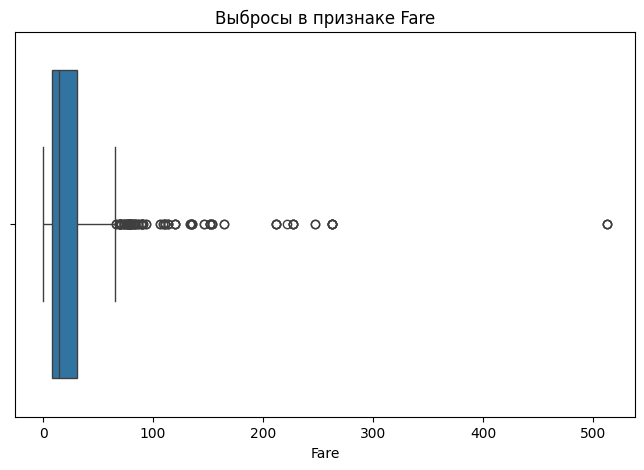

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title("Выбросы в признаке Fare")
plt.show()

In [ ]:
df = df[df['Fare'] < 300]

Преобразуем возраст

In [ ]:
df['Age_log'] = np.log(df['Age'] + 1)

Выживаемость по полу

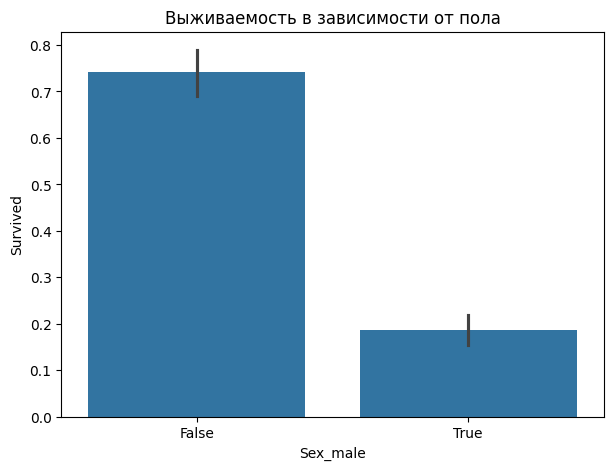

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(x='Sex_male', y='Survived', data=df)
plt.title("Выживаемость в зависимости от пола")
plt.show()

Выживаемость по классу

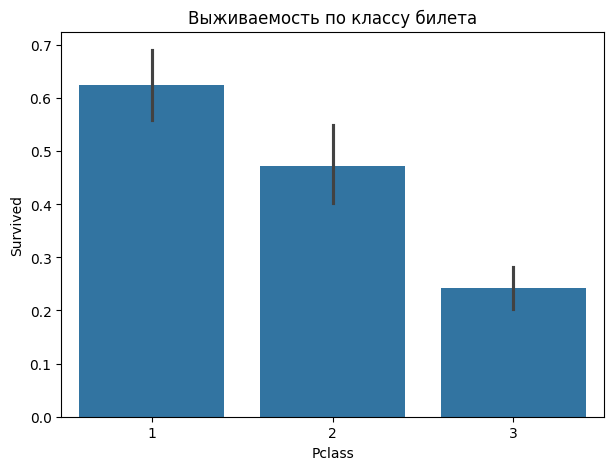

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Выживаемость по классу билета")
plt.show()

Обучение модели после очистки

In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict(X_test)

acc_clean = accuracy_score(y_test, pred)

print("Accuracy после обработки:", acc_clean)

Accuracy после обработки: 0.8314606741573034


Сравним рез-ты

In [ ]:
print("Accuracy до обработки:", acc_simple)
print("Accuracy после обработки:", acc_clean)

Accuracy до обработки: 0.6993006993006993
Accuracy после обработки: 0.8314606741573034


    Выводы

Какие преобразования были сделаны

- удалены признаки PassengerId, Name, Ticket, Cabin
- заполнены пропуски в Age средним значением
- заполнены пропуски в Embarked самыми частым значением
- категории переведены в числа
- удалены выбросы в Fare
- добавлен логарифм возраста

Эти действия помогают модели лучше работать с данными.


Сравнение моделей:
После обработки данных Accuracy увеличилось.
Видим, что очистка и подготовка данных
улучшают качество модели.


Мнение о работе с данными:
Даже простая модель может показать хорошие результаты, если данные заранее подготовили.


Нужно ли делать это для больших данных?
Да. Наличие больших данных не гарантирует качества данных.